# Normarc Drift Monitor — Exploration

EDA over 24 weeks of synthetic credit scoring inferences.  
**Story:** stable model → drift injected at week 18 → detection → alert.

---

In [ ]:
import sys
from pathlib import Path

import duckdb
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Proyecto root para imports
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from metrics.psi import compute_psi_for_week
from metrics.ece import compute_ece_for_week, get_calibration_curve

# --- Paleta Normarc ---
GOLD = "#d4a853"
GOLD_DIM = "#a78338"
GOLD_DEEP = "#7a5f28"
CREAM = "#f5e6c4"
BG = "#0c0a06"
BG2 = "#111008"
BG3 = "#1a170e"
TEXT_DIM = "#8a7a55"
GREEN = "#7bc77e"
RED = "#d47a6a"
BLUE = "#7aa8d4"

def normarc_style():
    """Apply Normarc dark theme to matplotlib."""
    plt.rcParams.update({
        "figure.facecolor": BG2,
        "axes.facecolor": BG3,
        "axes.edgecolor": GOLD_DEEP,
        "axes.labelcolor": CREAM,
        "axes.titlepad": 14,
        "text.color": CREAM,
        "xtick.color": TEXT_DIM,
        "ytick.color": TEXT_DIM,
        "grid.color": GOLD_DEEP,
        "grid.alpha": 0.15,
        "legend.facecolor": BG3,
        "legend.edgecolor": GOLD_DEEP,
        "legend.labelcolor": CREAM,
        "font.size": 11,
    })

normarc_style()
print("Setup OK")

Setup OK


In [2]:
# Cargar datos en DuckDB
CSV_PATH = PROJECT_ROOT / "data" / "inference_logs.csv"
con = duckdb.connect(":memory:")
con.execute(f"""
    CREATE TABLE logs AS
    SELECT *,
        FLOOR(DATEDIFF('day', (SELECT MIN(fecha) FROM read_csv_auto('{CSV_PATH.as_posix()}')), fecha) / 7) AS week_num
    FROM read_csv_auto('{CSV_PATH.as_posix()}',
        types={{
            'fecha': 'DATE', 'cliente_id': 'VARCHAR', 'score': 'DOUBLE',
            'prob_default': 'DOUBLE', 'ingreso_mensual': 'DOUBLE',
            'edad': 'INTEGER', 'meses_historial': 'INTEGER', 'default_real': 'INTEGER'
        }})
""")

summary = con.execute("""
    SELECT
        COUNT(*) as total_records,
        COUNT(DISTINCT week_num) as total_weeks,
        MIN(fecha) as first_date,
        MAX(fecha) as last_date
    FROM logs
""").fetchone()

print(f"Records: {summary[0]:,}")
print(f"Weeks:   {summary[1]}")
print(f"Period:  {summary[2]} → {summary[3]}")

Records: 12,000
Weeks:   24
Period:  2024-01-01 → 2024-06-16


In [3]:
# Obtener límites de cada semana
weeks = con.execute("""
    SELECT week_num, MIN(fecha) as w_start, MAX(fecha) as w_end, COUNT(*) as n
    FROM logs GROUP BY week_num ORDER BY week_num
""").fetchall()

BASELINE_WEEKS = 8
DRIFT_WEEK = 18
PSI_THRESHOLD = 0.20
ECE_THRESHOLD = 0.05
FEATURES = ["ingreso_mensual", "edad", "meses_historial", "score"]

baseline_start = str(weeks[0][1])
baseline_end = str(weeks[BASELINE_WEEKS - 1][2])

print(f"Baseline: {baseline_start} → {baseline_end} (weeks 0-{BASELINE_WEEKS-1})")
print(f"Weeks loaded: {len(weeks)}")

Baseline: 2024-01-01 → 2024-02-25 (weeks 0-7)
Weeks loaded: 24


## 1. Feature distributions — Baseline vs Drift

Side-by-side comparison of all monitored features. The drift in `ingreso_mensual` at week 18 is the primary signal.

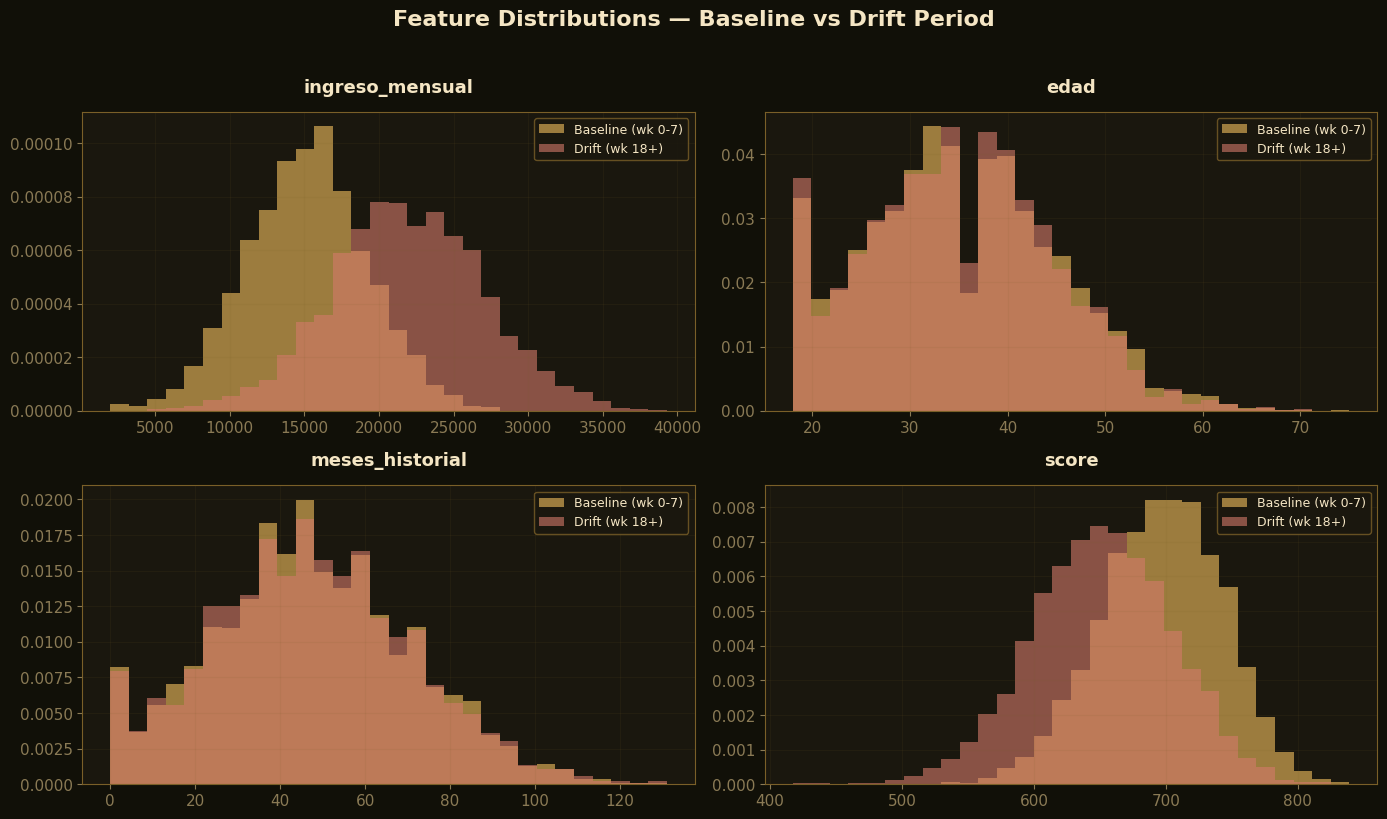

In [4]:
# Distribuciones: baseline vs post-drift
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, feature in zip(axes.flat, FEATURES):
    baseline_vals = np.asarray(con.execute(
        f"SELECT {feature} FROM logs WHERE week_num < {BASELINE_WEEKS}"
    ).fetchnumpy()[feature], dtype=float)

    drift_vals = np.asarray(con.execute(
        f"SELECT {feature} FROM logs WHERE week_num >= {DRIFT_WEEK}"
    ).fetchnumpy()[feature], dtype=float)

    bins = np.histogram_bin_edges(np.concatenate([baseline_vals, drift_vals]), bins=30)
    ax.hist(baseline_vals, bins=bins, alpha=0.7, color=GOLD, label="Baseline (wk 0-7)", density=True)
    ax.hist(drift_vals, bins=bins, alpha=0.6, color=RED, label="Drift (wk 18+)", density=True)
    ax.set_title(feature, fontsize=13, fontweight="bold", color=CREAM)
    ax.legend(fontsize=9, framealpha=0.8)
    ax.grid(True, alpha=0.1)

fig.suptitle("Feature Distributions — Baseline vs Drift Period", fontsize=16,
             fontweight="bold", color=CREAM, y=1.02)
plt.tight_layout()
plt.show()

## 2. PSI over time — per feature

Weekly PSI for each monitored feature. The threshold line at 0.20 marks the alert boundary. `ingreso_mensual` explodes at week 18.

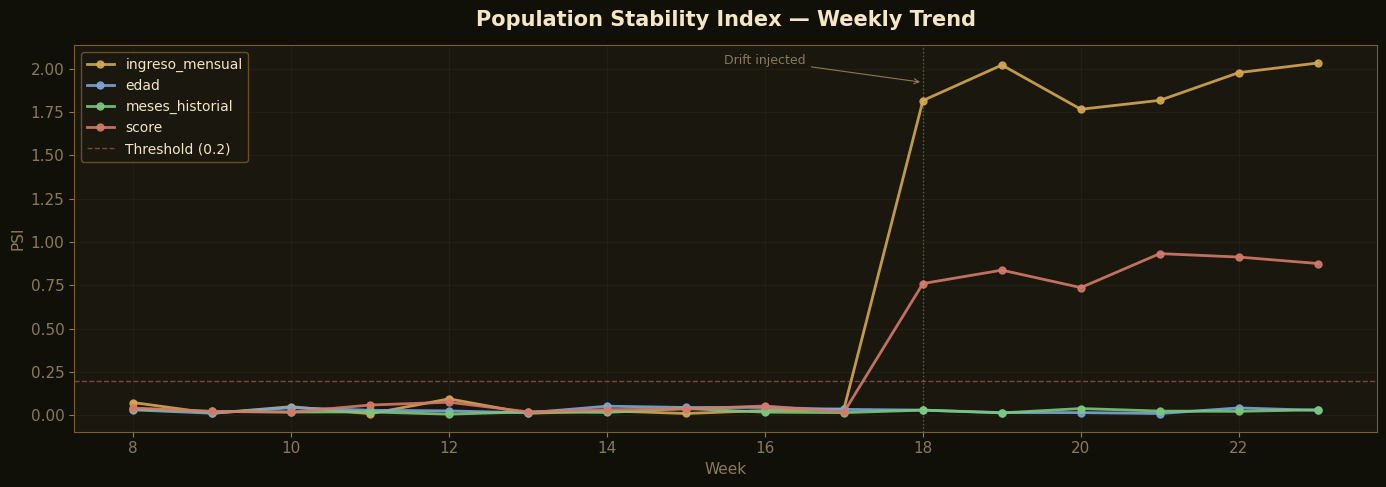

In [5]:
# Calcular PSI por semana para cada feature
psi_over_time = {f: [] for f in FEATURES}
week_nums = []

for wk_num, wk_start, wk_end, n in weeks[BASELINE_WEEKS:]:
    week_nums.append(int(wk_num))
    psi = compute_psi_for_week(
        con, "logs", baseline_start, baseline_end,
        str(wk_start), str(wk_end), FEATURES
    )
    for f in FEATURES:
        psi_over_time[f].append(psi[f])

# Plot
feature_colors = {
    "ingreso_mensual": GOLD,
    "edad": BLUE,
    "meses_historial": GREEN,
    "score": RED,
}

fig, ax = plt.subplots(figsize=(14, 5))

for feature in FEATURES:
    ax.plot(week_nums, psi_over_time[feature], marker="o", markersize=5,
            linewidth=2, label=feature, color=feature_colors[feature], alpha=0.9)

ax.axhline(y=PSI_THRESHOLD, color=RED, linestyle="--", alpha=0.5, linewidth=1, label=f"Threshold ({PSI_THRESHOLD})")
ax.axvline(x=DRIFT_WEEK, color=CREAM, linestyle=":", alpha=0.3, linewidth=1)
ax.annotate("Drift injected", xy=(DRIFT_WEEK, ax.get_ylim()[1] * 0.9),
            fontsize=9, color=TEXT_DIM, ha="center",
            arrowprops=dict(arrowstyle="->", color=TEXT_DIM, lw=0.8),
            xytext=(DRIFT_WEEK - 2, ax.get_ylim()[1] * 0.95))

ax.set_xlabel("Week", fontsize=11, color=TEXT_DIM)
ax.set_ylabel("PSI", fontsize=11, color=TEXT_DIM)
ax.set_title("Population Stability Index — Weekly Trend", fontsize=15, fontweight="bold", color=CREAM)
ax.legend(fontsize=10, framealpha=0.8, loc="upper left")
ax.grid(True, alpha=0.1)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 3. ECE over time — Calibration degradation

Expected Calibration Error per week. Pre-drift the model stays well under 0.05. Post-drift, ECE jumps to ~0.10+ as the model underestimates default risk for the new higher-income segment.

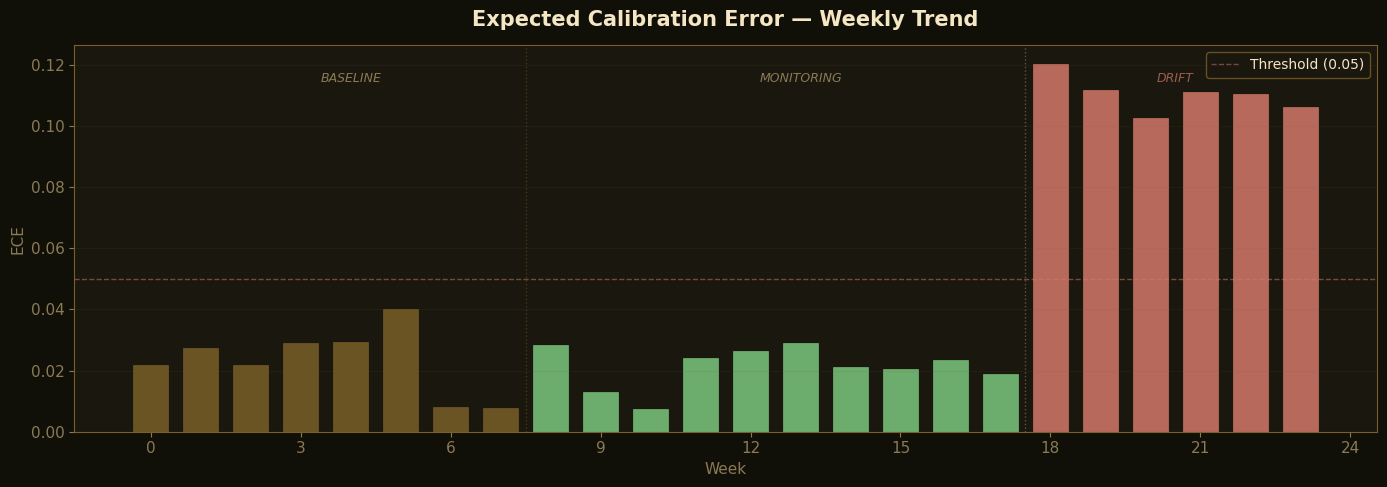

In [6]:
# ECE por semana (todas las semanas, incluyendo baseline)
ece_values = []
all_week_nums = []

for wk_num, wk_start, wk_end, n in weeks:
    all_week_nums.append(int(wk_num))
    ece = compute_ece_for_week(con, "logs", str(wk_start), str(wk_end))
    ece_values.append(ece)

fig, ax = plt.subplots(figsize=(14, 5))

# Colorear barras según zona
bar_colors = []
for i, (wk, ece) in enumerate(zip(all_week_nums, ece_values)):
    if wk < BASELINE_WEEKS:
        bar_colors.append(GOLD_DEEP)  # Baseline (referencia)
    elif ece > ECE_THRESHOLD:
        bar_colors.append(RED)
    else:
        bar_colors.append(GREEN)

bars = ax.bar(all_week_nums, ece_values, color=bar_colors, alpha=0.85, width=0.7,
              edgecolor=[c + "80" for c in bar_colors], linewidth=0.5)

ax.axhline(y=ECE_THRESHOLD, color=RED, linestyle="--", alpha=0.5, linewidth=1,
           label=f"Threshold ({ECE_THRESHOLD})")
ax.axvline(x=BASELINE_WEEKS - 0.5, color=GOLD_DIM, linestyle=":", alpha=0.3, linewidth=1)
ax.axvline(x=DRIFT_WEEK - 0.5, color=CREAM, linestyle=":", alpha=0.3, linewidth=1)

# Anotaciones
ax.text(BASELINE_WEEKS / 2, max(ece_values) * 0.95, "BASELINE",
        ha="center", fontsize=9, color=TEXT_DIM, fontstyle="italic")
ax.text((BASELINE_WEEKS + DRIFT_WEEK) / 2, max(ece_values) * 0.95, "MONITORING",
        ha="center", fontsize=9, color=TEXT_DIM, fontstyle="italic")
ax.text((DRIFT_WEEK + max(all_week_nums)) / 2, max(ece_values) * 0.95, "DRIFT",
        ha="center", fontsize=9, color=RED, fontstyle="italic", alpha=0.7)

ax.set_xlabel("Week", fontsize=11, color=TEXT_DIM)
ax.set_ylabel("ECE", fontsize=11, color=TEXT_DIM)
ax.set_title("Expected Calibration Error — Weekly Trend", fontsize=15, fontweight="bold", color=CREAM)
ax.legend(fontsize=10, framealpha=0.8)
ax.grid(True, axis="y", alpha=0.1)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 4. Reliability Diagrams — Before vs After Drift

Calibration curves comparing a stable week (week 10) and a drift week (week 20). The gap between predicted probabilities and observed default rates widens significantly after drift.

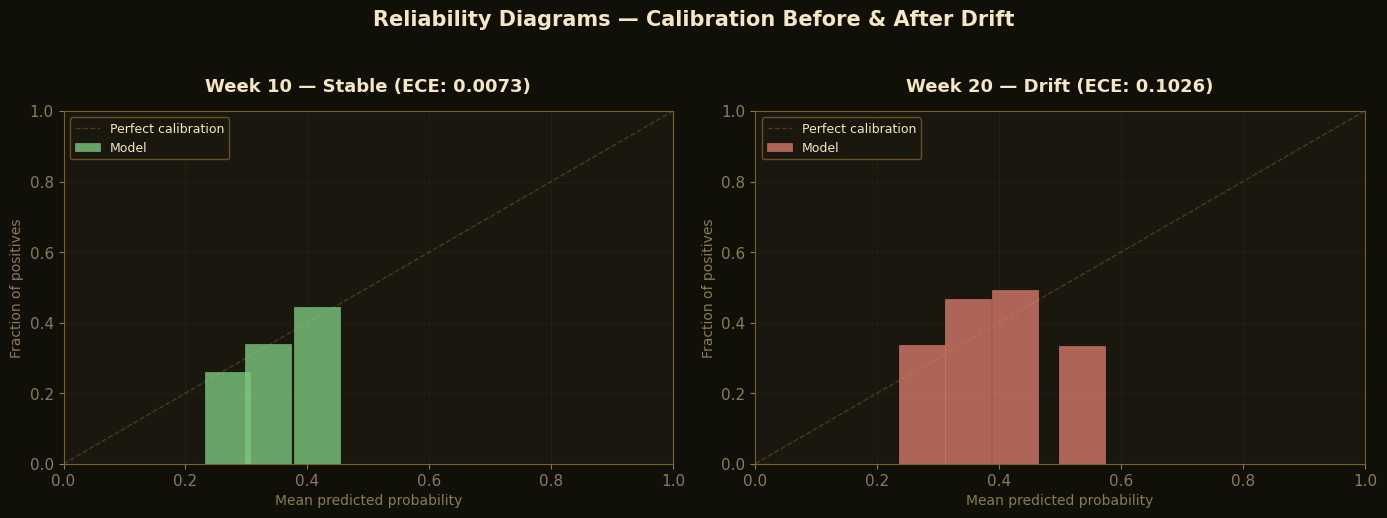

In [7]:
# Reliability diagrams: semana estable vs semana con drift
stable_week = 10
drift_week_example = 20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, wk, title_suffix, accent in [
    (ax1, stable_week, "Stable", GREEN),
    (ax2, drift_week_example, "Drift", RED),
]:
    wk_start = str(weeks[wk][1])
    wk_end = str(weeks[wk][2])
    mp, fp, bc = get_calibration_curve(con, "logs", wk_start, wk_end)
    ece = compute_ece_for_week(con, "logs", wk_start, wk_end)

    mask = bc > 0
    ax.plot([0, 1], [0, 1], color=GOLD_DEEP, linestyle="--", alpha=0.5, linewidth=1,
            label="Perfect calibration")
    ax.bar(mp[mask], fp[mask], width=0.075, color=accent, alpha=0.8,
           edgecolor=accent + "80", linewidth=0.5, label="Model", zorder=3)
    ax.set_xlabel("Mean predicted probability", fontsize=10, color=TEXT_DIM)
    ax.set_ylabel("Fraction of positives", fontsize=10, color=TEXT_DIM)
    ax.set_title(f"Week {wk} — {title_suffix} (ECE: {ece:.4f})",
                 fontsize=13, fontweight="bold", color=CREAM)
    ax.legend(fontsize=9, framealpha=0.8, loc="upper left")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.1)

fig.suptitle("Reliability Diagrams — Calibration Before & After Drift",
             fontsize=15, fontweight="bold", color=CREAM, y=1.03)
plt.tight_layout()
plt.show()

## 5. ingreso_mensual — The drift story

Zoomed view of the primary drift feature: weekly mean and standard deviation of `ingreso_mensual`. The structural shift from ~15K MXN to ~22K MXN is unmistakable.

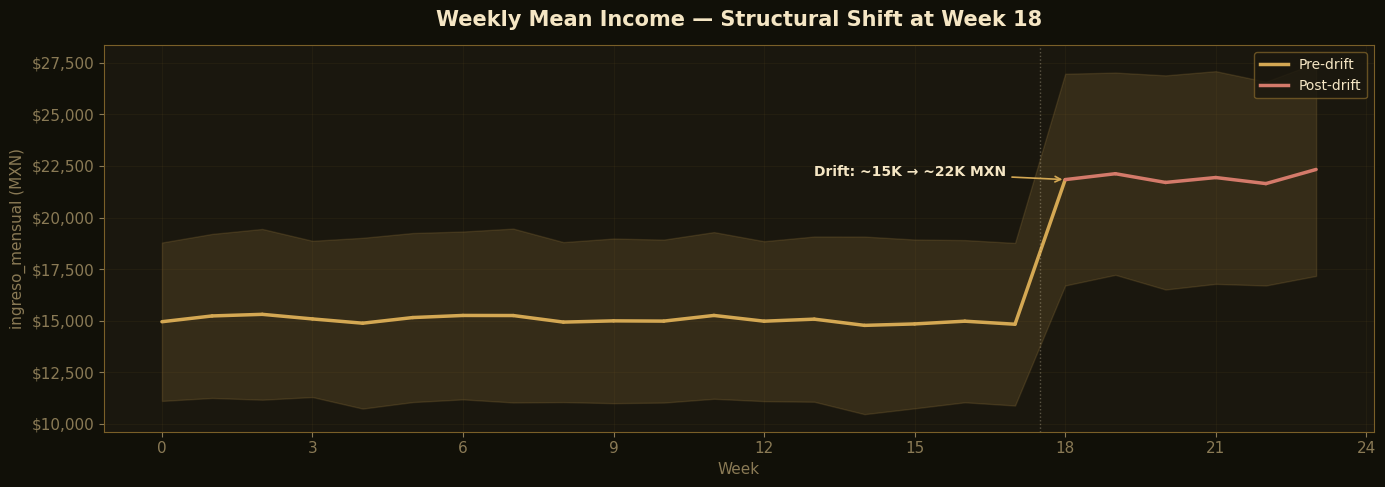

In [8]:
# ingreso_mensual: media y std por semana
stats = con.execute("""
    SELECT week_num,
           AVG(ingreso_mensual) as mean_ingreso,
           STDDEV(ingreso_mensual) as std_ingreso
    FROM logs
    GROUP BY week_num
    ORDER BY week_num
""").fetchall()

wk_n = [int(r[0]) for r in stats]
means = [r[1] for r in stats]
stds = [r[2] for r in stats]

fig, ax = plt.subplots(figsize=(14, 5))

# Banda de ±1 std
ax.fill_between(wk_n, [m - s for m, s in zip(means, stds)],
                [m + s for m, s in zip(means, stds)],
                alpha=0.15, color=GOLD)

# Colorear línea por zona
for i in range(len(wk_n) - 1):
    color = RED if wk_n[i] >= DRIFT_WEEK else GOLD
    ax.plot(wk_n[i:i+2], means[i:i+2], color=color, linewidth=2.5, solid_capstyle="round")

ax.plot([], [], color=GOLD, linewidth=2.5, label="Pre-drift")
ax.plot([], [], color=RED, linewidth=2.5, label="Post-drift")

ax.axvline(x=DRIFT_WEEK - 0.5, color=CREAM, linestyle=":", alpha=0.3, linewidth=1)
ax.annotate("Drift: ~15K → ~22K MXN", xy=(DRIFT_WEEK, means[DRIFT_WEEK]),
            fontsize=10, color=CREAM, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=GOLD, lw=1.2),
            xytext=(DRIFT_WEEK - 5, 22000))

ax.set_xlabel("Week", fontsize=11, color=TEXT_DIM)
ax.set_ylabel("ingreso_mensual (MXN)", fontsize=11, color=TEXT_DIM)
ax.set_title("Weekly Mean Income — Structural Shift at Week 18",
             fontsize=15, fontweight="bold", color=CREAM)
ax.legend(fontsize=10, framealpha=0.8)
ax.grid(True, alpha=0.1)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

## 6. Default rate — Model underestimates risk post-drift

The observed default rate vs the model's average predicted probability, week by week. After drift, the model predicts lower risk than what actually materializes — a dangerous miscalibration in lending.

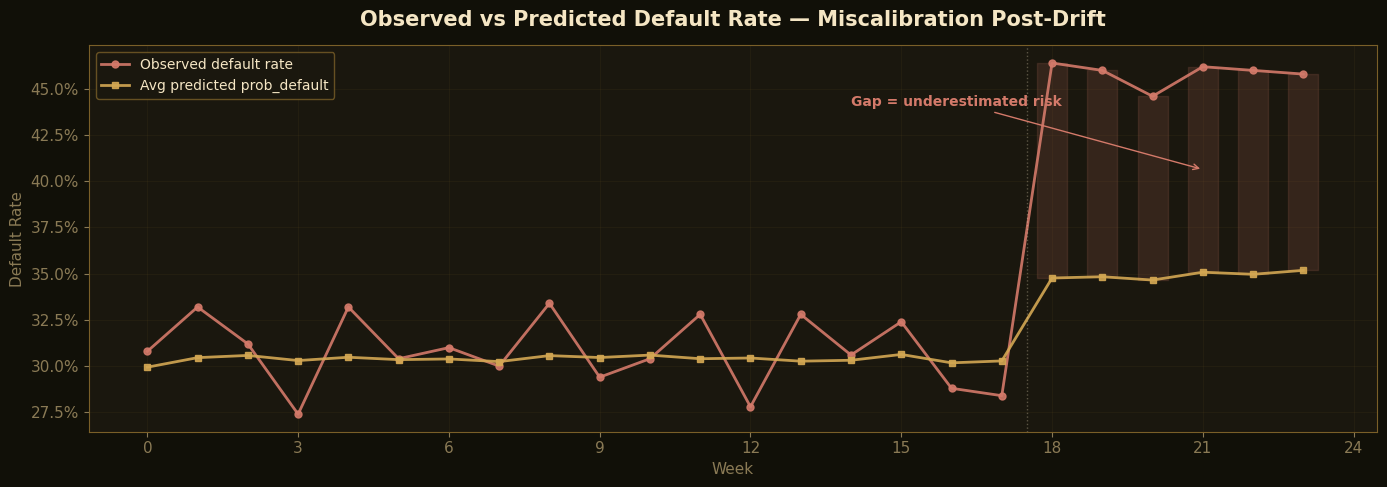

In [9]:
# Default rate observada vs predicha por semana
rates = con.execute("""
    SELECT week_num,
           AVG(default_real) as observed_rate,
           AVG(prob_default) as predicted_rate
    FROM logs
    GROUP BY week_num
    ORDER BY week_num
""").fetchall()

wk_n = [int(r[0]) for r in rates]
observed = [r[1] for r in rates]
predicted = [r[2] for r in rates]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(wk_n, observed, marker="o", markersize=5, linewidth=2, color=RED,
        label="Observed default rate", alpha=0.9)
ax.plot(wk_n, predicted, marker="s", markersize=5, linewidth=2, color=GOLD,
        label="Avg predicted prob_default", alpha=0.9)

# Sombrear la brecha post-drift
for i in range(len(wk_n)):
    if wk_n[i] >= DRIFT_WEEK:
        ax.fill_between([wk_n[i] - 0.3, wk_n[i] + 0.3],
                        predicted[i], observed[i],
                        alpha=0.15, color=RED)

ax.axvline(x=DRIFT_WEEK - 0.5, color=CREAM, linestyle=":", alpha=0.3, linewidth=1)
ax.annotate("Gap = underestimated risk", xy=(21, (observed[21] + predicted[21]) / 2),
            fontsize=10, color=RED, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=RED, lw=1),
            xytext=(14, max(observed) * 0.95))

ax.set_xlabel("Week", fontsize=11, color=TEXT_DIM)
ax.set_ylabel("Default Rate", fontsize=11, color=TEXT_DIM)
ax.set_title("Observed vs Predicted Default Rate — Miscalibration Post-Drift",
             fontsize=15, fontweight="bold", color=CREAM)
ax.legend(fontsize=10, framealpha=0.8)
ax.grid(True, alpha=0.1)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1%}"))

plt.tight_layout()
plt.show()

## 7. Combined dashboard — The full picture

PSI + ECE + default rate gap in a single view. This is the chart that tells the governance story end-to-end.

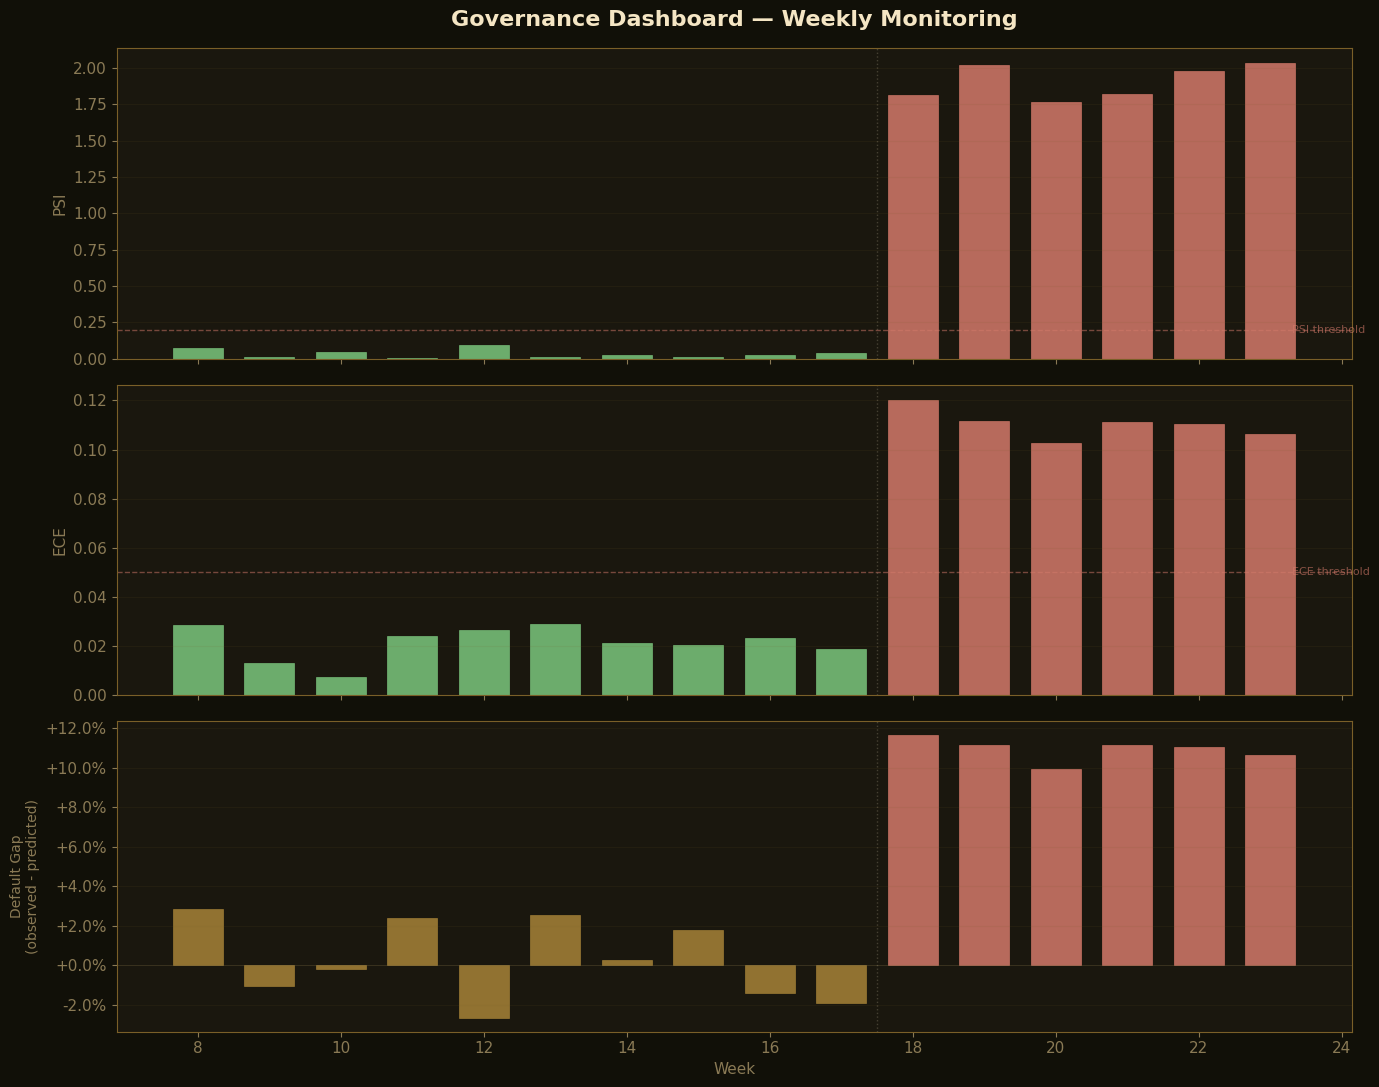

In [10]:
# Dashboard combinado: 3 paneles
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

monitoring_weeks = list(range(BASELINE_WEEKS, len(weeks)))

# --- Panel 1: PSI (ingreso_mensual) ---
psi_ingreso = psi_over_time["ingreso_mensual"]
colors_psi = [RED if v > PSI_THRESHOLD else GREEN for v in psi_ingreso]
ax1.bar(week_nums, psi_ingreso, color=colors_psi, alpha=0.85, width=0.7,
        edgecolor=[c + "80" for c in colors_psi], linewidth=0.5)
ax1.axhline(y=PSI_THRESHOLD, color=RED, linestyle="--", alpha=0.5, linewidth=1)
ax1.axvline(x=DRIFT_WEEK - 0.5, color=CREAM, linestyle=":", alpha=0.2, linewidth=1)
ax1.set_ylabel("PSI", fontsize=11, color=TEXT_DIM)
ax1.set_title("Governance Dashboard — Weekly Monitoring",
              fontsize=16, fontweight="bold", color=CREAM, pad=16)
ax1.text(max(week_nums) + 0.3, PSI_THRESHOLD, "PSI threshold",
         fontsize=8, color=RED, alpha=0.6, va="center")
ax1.grid(True, axis="y", alpha=0.1)

# --- Panel 2: ECE ---
ece_monitoring = ece_values[BASELINE_WEEKS:]
colors_ece = [RED if v > ECE_THRESHOLD else GREEN for v in ece_monitoring]
ax2.bar(week_nums, ece_monitoring, color=colors_ece, alpha=0.85, width=0.7,
        edgecolor=[c + "80" for c in colors_ece], linewidth=0.5)
ax2.axhline(y=ECE_THRESHOLD, color=RED, linestyle="--", alpha=0.5, linewidth=1)
ax2.axvline(x=DRIFT_WEEK - 0.5, color=CREAM, linestyle=":", alpha=0.2, linewidth=1)
ax2.set_ylabel("ECE", fontsize=11, color=TEXT_DIM)
ax2.text(max(week_nums) + 0.3, ECE_THRESHOLD, "ECE threshold",
         fontsize=8, color=RED, alpha=0.6, va="center")
ax2.grid(True, axis="y", alpha=0.1)

# --- Panel 3: Default rate gap ---
obs_monitoring = [observed[i] for i in monitoring_weeks]
pred_monitoring = [predicted[i] for i in monitoring_weeks]
gap = [o - p for o, p in zip(obs_monitoring, pred_monitoring)]
colors_gap = [RED if wk >= DRIFT_WEEK else GOLD_DIM for wk in week_nums]
ax3.bar(week_nums, gap, color=colors_gap, alpha=0.85, width=0.7,
        edgecolor=[c + "80" for c in colors_gap], linewidth=0.5)
ax3.axhline(y=0, color=TEXT_DIM, linestyle="-", alpha=0.3, linewidth=0.5)
ax3.axvline(x=DRIFT_WEEK - 0.5, color=CREAM, linestyle=":", alpha=0.2, linewidth=1)
ax3.set_xlabel("Week", fontsize=11, color=TEXT_DIM)
ax3.set_ylabel("Default Gap\n(observed - predicted)", fontsize=10, color=TEXT_DIM)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.1%}"))
ax3.grid(True, axis="y", alpha=0.1)
ax3.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

---

**Takeaway:** Without continuous monitoring, the fintech would have continued approving credits using a model that systematically underestimates default risk for a new population segment. PSI catches the distributional shift immediately. ECE confirms the calibration has degraded. The governance agent detects both — before a regulator asks.

*Built with Normarc — governance that bends with your architecture, not against it.*

In [11]:
con.close()